#   RESPONSI MODUL 2
Tegu Ilham Pebrian Saputra F1D02410097

In [34]:
import cv2 as cv 
import numpy as np 
import matplotlib.pyplot as plt 

###   Tampilkan Citra

(1058, 736, 3)


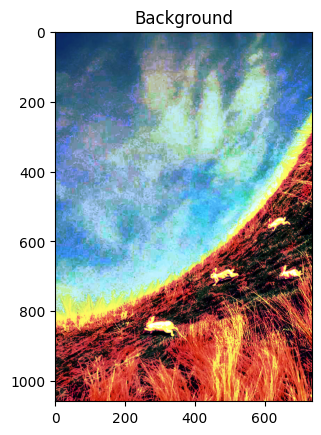

In [35]:
citra_bg = cv.imread('background.png')
plt.imshow(citra_bg)
plt.title("Background")
print(citra_bg.shape)

###   Pecah R, G, B

Text(0.5, 1.0, 'Citra Blue')

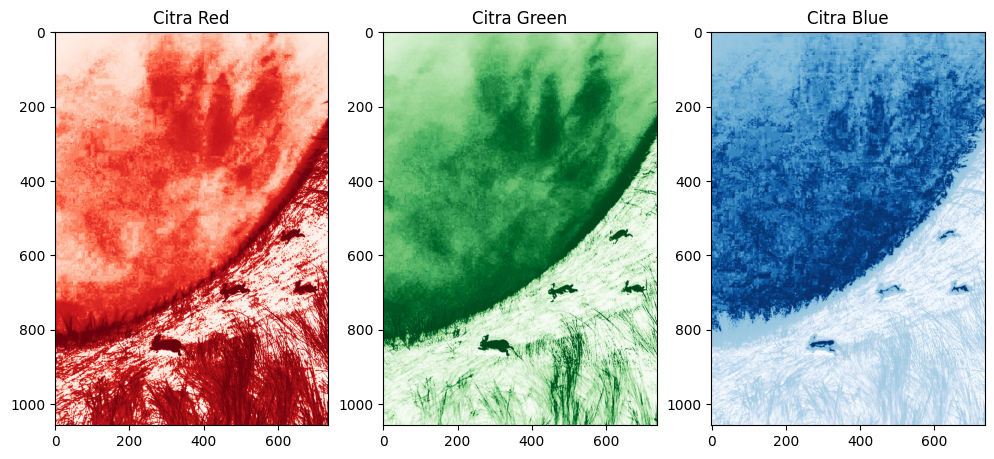

In [36]:
citra_bg_awal = cv.cvtColor(citra_bg, cv.COLOR_BGR2RGB)

blue = citra_bg_awal[:, :, 0]
green = citra_bg_awal[:, :, 1]
red = citra_bg_awal[:, :, 2]

plt.figure(figsize=(12, 7))

plt.subplot(1, 3, 1)
plt.imshow(red, cmap='Reds')
plt.title("Citra Red")

plt.subplot(1, 3, 2)
plt.imshow(green, cmap='Greens')
plt.title("Citra Green")

plt.subplot(1, 3, 3)
plt.imshow(blue, cmap='Blues')
plt.title("Citra Blue")

###  Histogram Channel

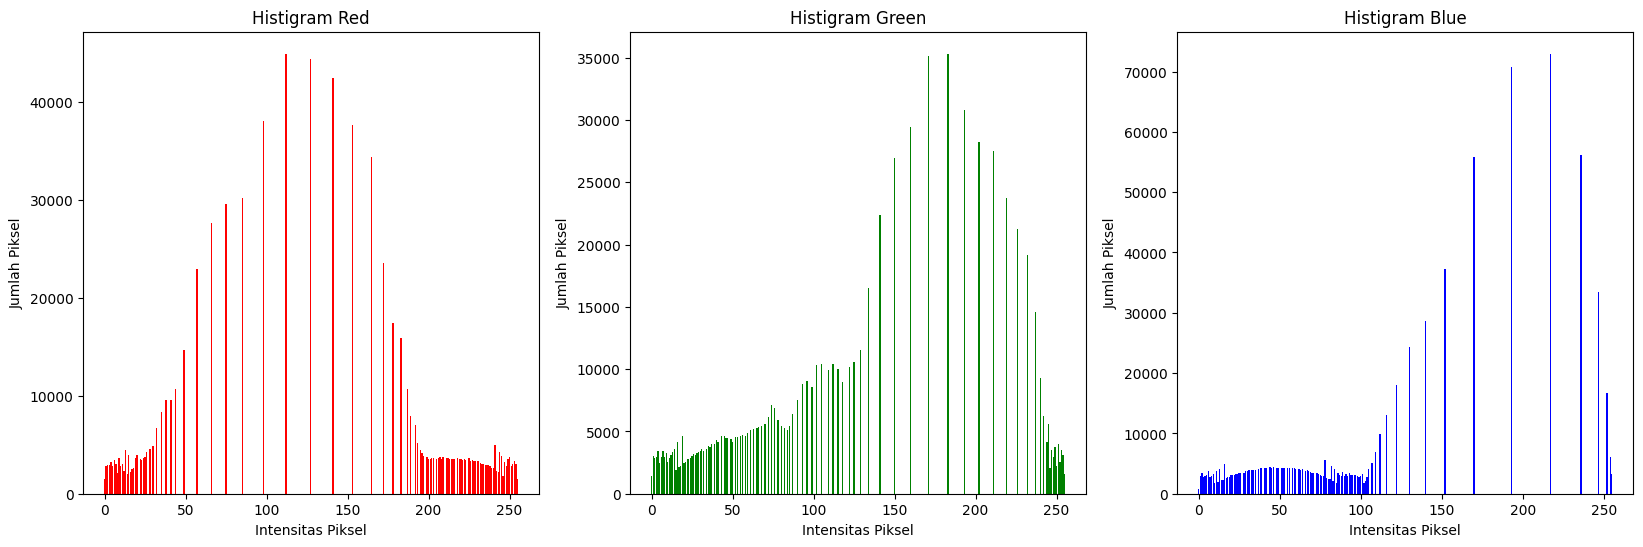

In [37]:
def buat_hist(citra):
    histogram = [0] * 256 
 
    height = len(citra) 
    width = len(citra[0]) if height > 0 else 0 
    for i in range(height): 
        for j in range(width): 
            val = int(citra[i][j])   
            histogram[val] += 1   
 
    return histogram

def plot_histogram(hist_target, hist_sps, color_target, color_sps, lokasi): 
    plt.bar(range(256), hist_target, color=color_target, alpha=0.7, label='Target', width=0.8)
    
    plt.bar(range(256), hist_sps, color=color_sps, alpha=0.7, label='Setelah Spesifikasi', width=0.8)
    
    plt.xlabel('Intensitas Piksel')
    plt.ylabel('Jumlah Piksel')
    
    plt.legend(loc=lokasi)

def plot_hist(histogram, title, ImgColor):
    plt.xlabel("Intensitas Piksel")
    plt.title(title)
    plt.ylabel("Jumlah Piksel")
    plt.bar(range(256), histogram, color=ImgColor, width=0.8)

plt.figure(figsize=(20, 6))

plt.subplot(1, 3, 1)
hist_red = buat_hist(red)
plot_hist(hist_red, 'Histigram Red', 'red')

plt.subplot(1, 3, 2)
hist_green = buat_hist(green)
plot_hist(hist_green, 'Histigram Green', 'green')

plt.subplot(1, 3, 3)
hist_blue = buat_hist(blue)
plot_hist(hist_blue, 'Histigram Blue', 'blue')

### Citra Target

Text(0.5, 1.0, 'Blue Target')

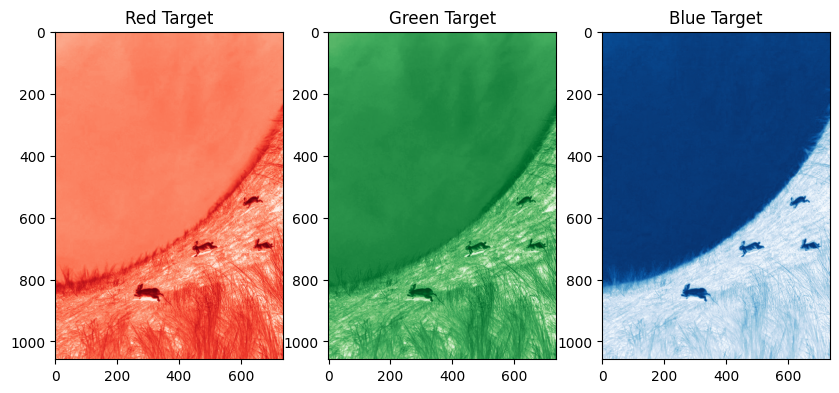

In [38]:
red_target = cv.imread('red_target.png', 0)
green_target = cv.imread('green_target.png', 0)
blue_target = cv.imread('blue_target.png', 0)

plt.figure(figsize=(10, 7))

plt.subplot(1, 3, 1)
plt.imshow(red_target, cmap='Reds')
plt.title("Red Target")

plt.subplot(1, 3, 2)
plt.imshow(green_target, cmap='Greens')
plt.title("Green Target")

plt.subplot(1, 3, 3)
plt.imshow(blue_target, cmap='Blues')
plt.title("Blue Target")


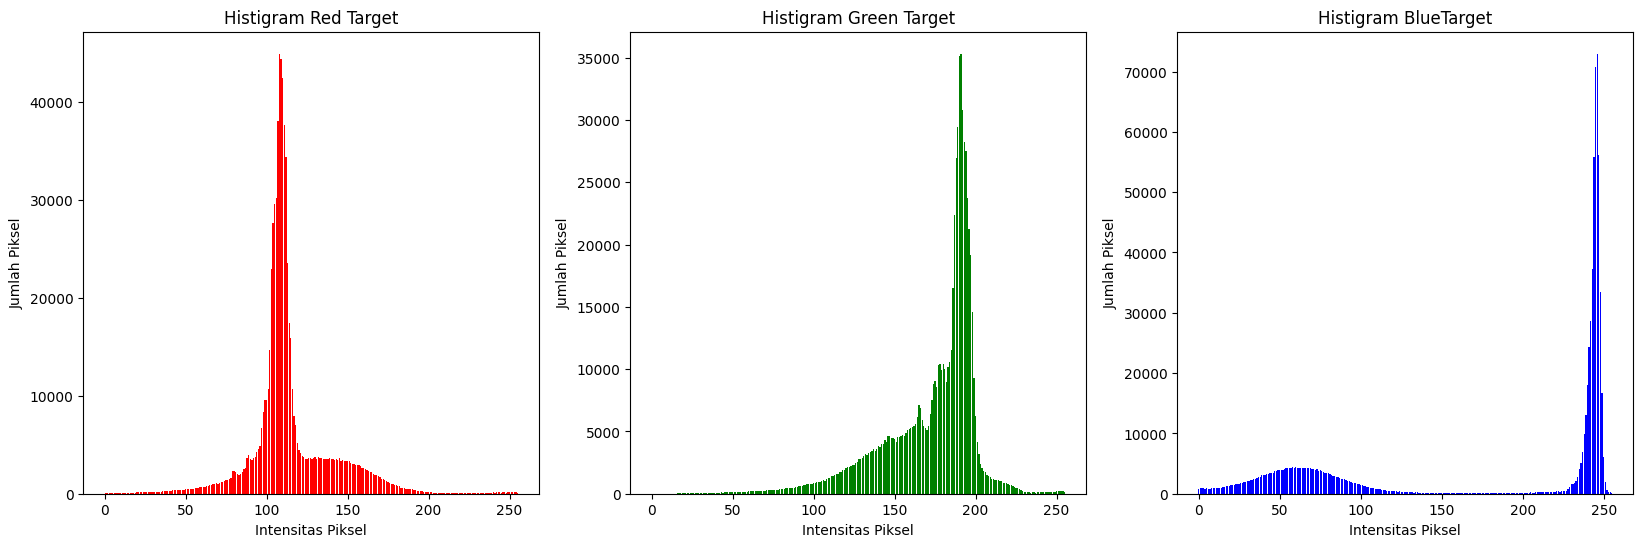

In [39]:
plt.figure(figsize=(20, 6))

plt.subplot(1, 3, 1)
hist_red_target = buat_hist(red_target)
plot_hist(hist_red_target, 'Histigram Red Target', 'red')

plt.subplot(1, 3, 2)
hist_green_target = buat_hist(green_target)
plot_hist(hist_green_target, 'Histigram Green Target', 'green')

plt.subplot(1, 3, 3)
hist_blue_target = buat_hist(blue_target)
plot_hist(hist_blue_target, 'Histigram BlueTarget', 'blue')

###   Spesifikasi Channel terhadap Target

Text(0.5, 1.0, 'Spesifikasi Blue')

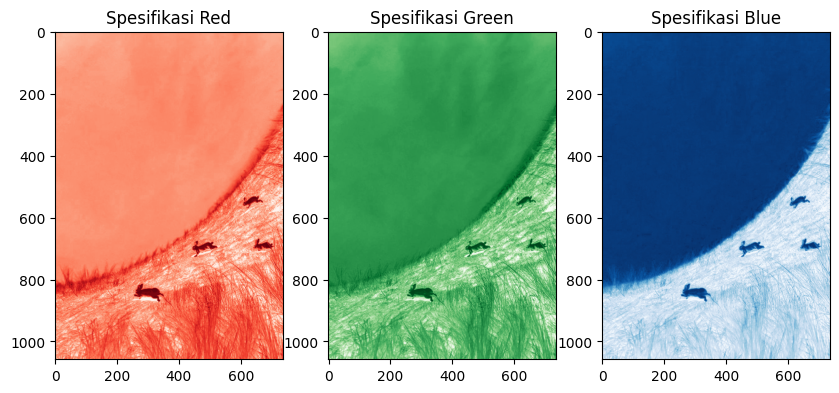

In [40]:
def spesifikasi_hist(citra_asal, citra_target): 
    hist_asal = np.zeros(256, dtype=int) 
    hist_target = np.zeros(256, dtype=int) 
    height_asal, width_asal = citra_asal.shape
    for i in range(height_asal):
        for j in range(width_asal):
            pixel = citra_asal[i, j]
            hist_asal[pixel] += 1
 
    height_target, width_target = citra_target.shape
    for i in range(height_target):
        for j in range(width_target):
            pixel = citra_target[i, j]
            hist_target[pixel] += 1
 
    cdf_asal = np.zeros(256, dtype=float) 
    cdf_target = np.zeros(256, dtype=float) 
 
    cdf_asal[0] = hist_asal[0] 
    cdf_target[0] = hist_target[0] 
 
    for i in range(1, 256):
        cdf_asal[i] = cdf_asal[i - 1] + hist_asal[i]
        cdf_target[i] = cdf_target[i - 1] + hist_target[i]
 
    cdf_asal = cdf_asal / cdf_asal[-1] 
    cdf_target = cdf_target / cdf_target[-1] 
 
    map_hist = np.zeros(256, dtype=np.uint8) 
 
    for i in range(256):
        selisih_terkecil = 1.0 
        index_target = 0
        for j in range(256):
            selisih = abs(cdf_asal[i] - cdf_target[j])
            if selisih < selisih_terkecil:
                selisih_terkecil = selisih
                index_target = j
        map_hist[i] = index_target
 
    height, width = citra_asal.shape 
    hasil = np.zeros((height, width), dtype=np.uint8) 
 
    for i in range(height):
        for j in range(width):
            pixel_lama = citra_asal[i, j]
            hasil[i, j] = map_hist[pixel_lama]
 
    return hasil

sps_red = spesifikasi_hist(red, red_target)
sps_green = spesifikasi_hist(green, green_target)
sps_blue = spesifikasi_hist(blue, blue_target)

plt.figure(figsize=(10, 7))

plt.subplot(1, 3, 1)
plt.imshow(sps_red, cmap='Reds')
plt.title("Spesifikasi Red")

plt.subplot(1, 3, 2)
plt.imshow(sps_green, cmap='Greens')
plt.title("Spesifikasi Green")

plt.subplot(1, 3, 3)
plt.imshow(sps_blue, cmap='Blues')
plt.title("Spesifikasi Blue")

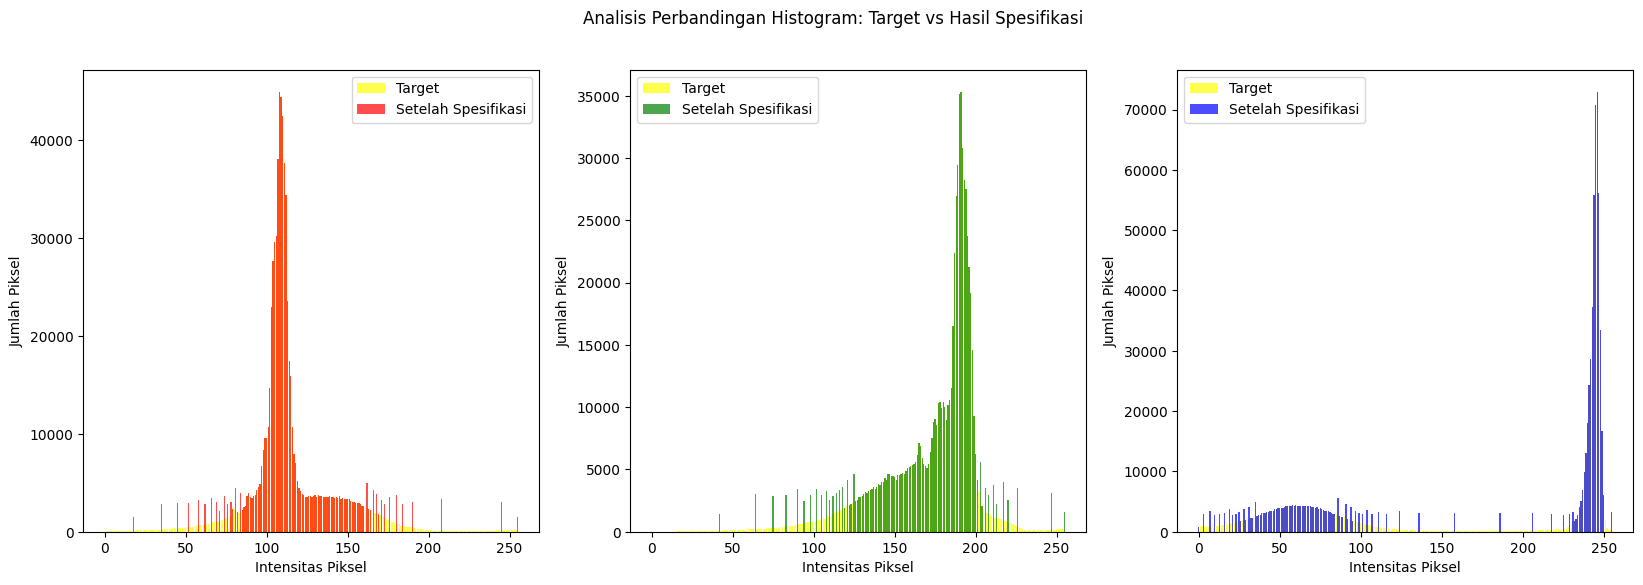

In [41]:
plt.figure(figsize=(20, 6))

plt.suptitle('Analisis Perbandingan Histogram: Target vs Hasil Spesifikasi')
plt.subplot(1, 3, 1)
hist_red_target = buat_hist(red_target)
hist_sps_red = buat_hist(sps_red)
perb_hist_red = plot_histogram(hist_red_target, hist_sps_red, 'yellow', 'red', 'upper right')

plt.subplot(1, 3, 2)
hist_green_target = buat_hist(green_target)
hist_sps_green = buat_hist(sps_green)
perb_hist_green = plot_histogram(hist_green_target, hist_sps_green, 'yellow', 'green', 'upper left')

plt.subplot(1, 3, 3)
hist_blue_target = buat_hist(blue_target)
hist_sps_blue = buat_hist(sps_blue)
perb_hist_blue = plot_histogram(hist_blue_target, hist_sps_blue, 'yellow', 'blue', 'upper left')

### Gabung Channel

Text(0.5, 1.0, 'Hasil Spesifikasi')

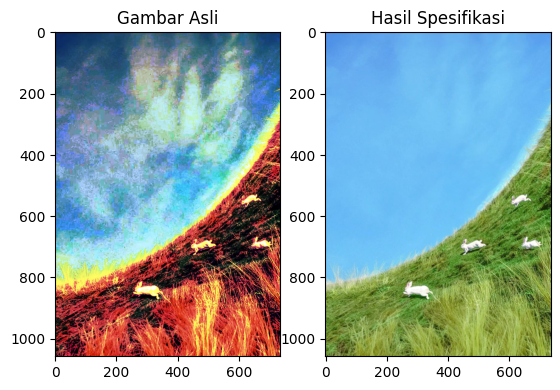

In [42]:
def merge_channel(r_channel, g_channel, b_channel):
    height = len(r_channel)
    width = len(r_channel[0])
    
    hasil = np.zeros((height, width, 3), dtype=np.uint8)
    
    for i in range(height):
        for j in range(width):
            hasil[i][j][0] = r_channel[i][j] 
            hasil[i][j][1] = g_channel[i][j] 
            hasil[i][j][2] = b_channel[i][j]
            
    return hasil

hasil_gabungan = merge_channel(sps_red, sps_green, sps_blue)

plt.subplot(1, 2, 1)
plt.imshow(citra_bg)
plt.title("Gambar Asli")

plt.subplot(1, 2, 2)
plt.imshow(hasil_gabungan)
plt.title("Hasil Spesifikasi")

###   Tampilkan Foreground

(529, 368, 3)


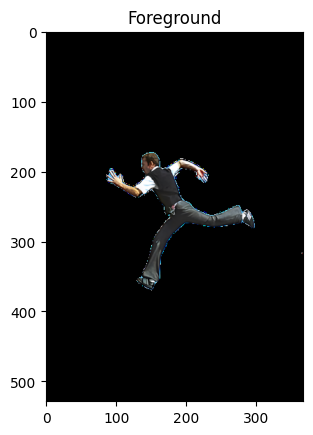

In [43]:
citra_foreground = cv.imread('foreground.png')
citra_foreground = cv.cvtColor(citra_foreground, cv.COLOR_BGR2RGB)
plt.imshow(citra_foreground)
plt.title("Foreground")
print(citra_foreground.shape)

In [44]:
def fungsi_dilatasi(image):
    h,w = image.shape
    dilated = np.zeros((h * 2, w * 2), dtype=image.dtype)
    for y in range(h * 2):
        for x in range(w * 2):
            dilated[y][x] = image[int(y/2)][int(x/2)]

    return dilated

Text(0.5, 1.0, 'Final Result')

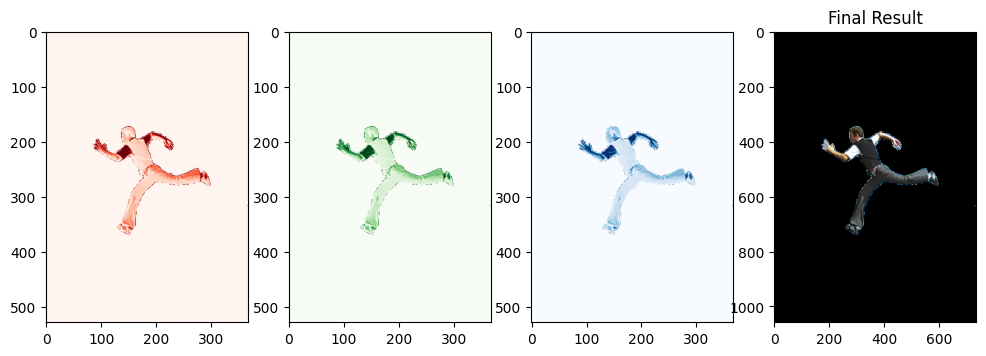

In [45]:
blue_fg = citra_foreground[:, :, 0]
green_fg = citra_foreground[:, :, 1]
red_fg = citra_foreground[:, :, 2]

red_dilated = fungsi_dilatasi(red_fg)
green_dilated = fungsi_dilatasi(green_fg)
blue_dilated = fungsi_dilatasi(blue_fg)

hasil_dilatasi = merge_channel(blue_dilated, green_dilated, red_dilated)

plt.figure(figsize=(12, 7))

plt.subplot(1, 4, 1)
plt.imshow(red_fg, cmap='Reds')

plt.subplot(1, 4, 2)
plt.imshow(green_fg, cmap='Greens')

plt.subplot(1, 4, 3)
plt.imshow(blue_fg, cmap='Blues')

plt.subplot(1, 4, 4)
plt.imshow(hasil_dilatasi)
plt.title("Final Result")


###   Gabung Background dan Foreground

(1058, 736, 3)


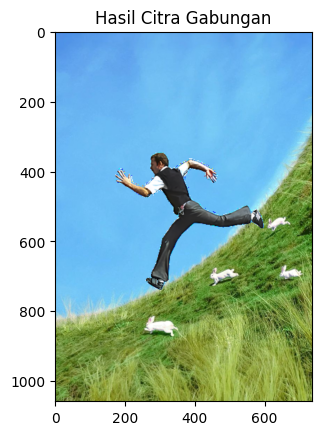

In [46]:
def gabung_citra(fg, bg):
    h, w, c = fg.shape
    hasil = np.zeros((h, w, c), dtype=np.uint8)
    
    for i in range(h):
        for j in range(w):
            b = fg[i][j][0]
            g = fg[i][j][1]
            r = fg[i][j][2]

            if r > 0 or g > 0 or b > 0:
                hasil[i][j] = fg[i][j]
            else:
                hasil[i][j] = bg[i][j]
                
    return hasil

citra_final = gabung_citra(hasil_dilatasi, hasil_gabungan)

plt.imshow(citra_final)
plt.title("Hasil Citra Gabungan")
print(citra_final.shape)
plt.show()


###  Potong 3 Bagian

Text(0.5, 1.0, 'Kanan')

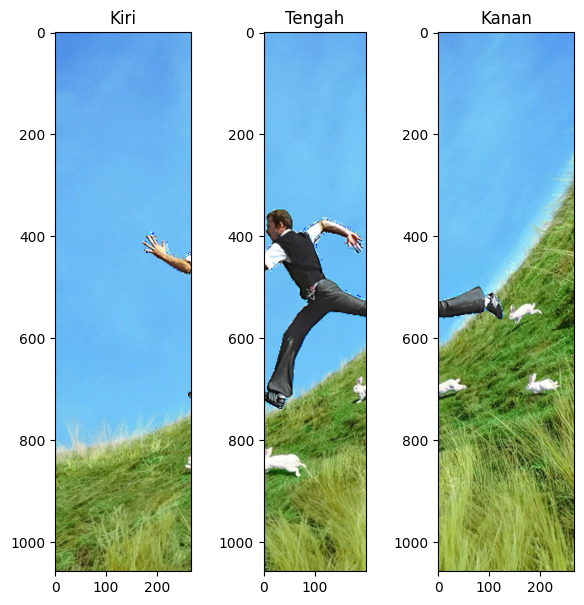

In [47]:
def fungsi_slicing(gambar, a, b, mode='H'):
    return gambar[a:b, :] if mode == 'H' else gambar[:, a:b]

kiri = fungsi_slicing(citra_final, 0, 268, 'Y')
tengah = fungsi_slicing(citra_final, 268, 468, 'Y')
kanan = fungsi_slicing(citra_final, 468, 736, 'Y')

plt.figure(figsize=(7, 7))

plt.subplot(1, 3, 1)
plt.imshow(kiri)
plt.title("Kiri")

plt.subplot(1, 3, 2)
plt.imshow(tengah)
plt.title("Tengah")

plt.subplot(1, 3, 3)
plt.imshow(kanan)
plt.title("Kanan")

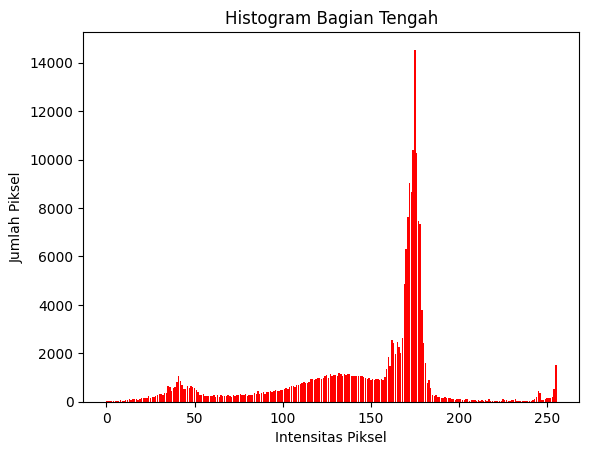

In [48]:
tengah_gray = cv.cvtColor(tengah, cv.COLOR_RGB2GRAY)
hist_tengah = buat_hist(tengah_gray)
plot_hist(hist_tengah, 'Histogram Bagian Tengah', 'red')

###   Ekualisasi Bagian Tengah

In [49]:
def ekualisasi(citra):
    h, w = citra.shape

    hist = np.zeros(256, dtype=int)
    for i in range(h):
        for j in range(w):
            intensitas = citra[i, j]
            hist[intensitas] += 1

    cdf = np.zeros(256, dtype=int)
    cdf[0] = hist[0]
    for i in range(1, 256):
        cdf[i] = cdf[i - 1] + hist[i]

    cdf_normal = np.round(cdf * 255 / (h * w)).astype(np.uint8)
    hasil = np.zeros_like(citra, dtype=np.uint8)
    for i in range(h):
        for j in range(w):
            hasil[i, j] = cdf_normal[citra[i, j]]

    return hasil

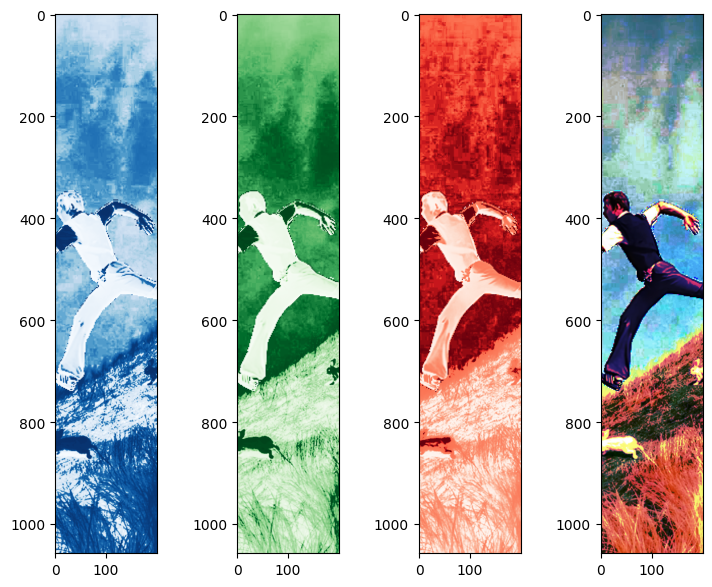

In [50]:
b_tengah = tengah[:, :, 0]
g_tengah = tengah[:, :, 1]
r_tengah = tengah[:, :, 2]

b_ekualisasi = ekualisasi(b_tengah)
g_ekualisasi = ekualisasi(g_tengah)
r_ekualisasi = ekualisasi(r_tengah)

gabung_tengah = merge_channel(b_ekualisasi, g_ekualisasi, r_ekualisasi)

plt.figure(figsize=(9, 7))

plt.subplot(1, 4, 1)
plt.imshow(b_ekualisasi, cmap='Blues')

plt.subplot(1, 4, 2)
plt.imshow(g_ekualisasi, cmap='Greens')

plt.subplot(1, 4, 3)
plt.imshow(r_ekualisasi, cmap='Reds')

plt.subplot(1, 4, 4)
plt.imshow(gabung_tengah)

Pengaruh proses ekualisasi pada gambar yaitu membuat gambar menjadi lebih terang dari sebelumnya. Ini tentunya sejalan dengan tujuan dari ekualisasi itu sendiri yaitu untuk membuat distribusi piksel menjadi semakin merata dan tidak menumpuk di satu sisi saja. Jika dilakukan ekualisasi pada setiap channel pun sama, semua pikselnya akan didistribusikan sampai merata sehingga membuat citra semakin cerah dari yang sebelumnya gelap.

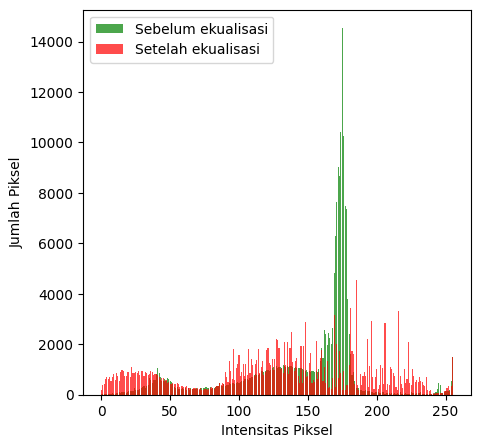

In [51]:
def plot_hist_ekualisasi(hist_sebelum, hist_setelah, color_sebelum, color_setelah, lokasi): 
    plt.bar(range(256), hist_sebelum, color=color_sebelum, alpha=0.7, label='Sebelum ekualisasi', width=0.8)
    
    plt.bar(range(256), hist_setelah, color=color_setelah, alpha=0.7, label='Setelah ekualisasi', width=0.8)
    
    plt.xlabel('Intensitas Piksel')
    plt.ylabel('Jumlah Piksel')
    
    plt.legend(loc=lokasi)

plt.figure(figsize=(5, 5))

gabung_tengah_gray = cv.cvtColor(gabung_tengah, cv.COLOR_RGB2GRAY)
hist_tengah_ekualisasi = buat_hist(gabung_tengah_gray)
plot_hist_ekualisasi(hist_tengah, hist_tengah_ekualisasi, 'green', 'red', 'upper left')
plt.show()

###   Gabung 3 Gambar

Text(0.5, 1.0, 'Gabung 3 gambar')

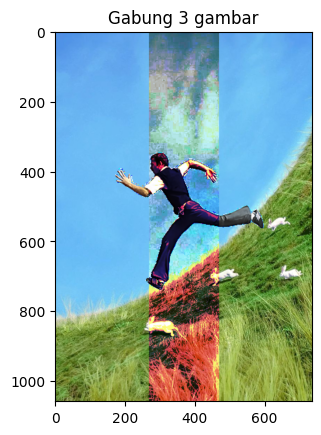

In [52]:
def merge_image(citra1, citra2, orientation='H'): 
     
    if orientation == 'H':   
        tinggi = max(citra1.shape[0], citra2.shape[0]) 
        lebar_total = citra1.shape[1] + citra2.shape[1] 
         
        if len(citra1.shape) == 2: 
            gabungan = np.zeros((tinggi, lebar_total), dtype=citra1.dtype) 
        else: 
            gabungan = np.zeros((tinggi, lebar_total, citra1.shape[2]), dtype=citra1.dtype) 
         
        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1 
        gabungan[0:citra2.shape[0], citra1.shape[1]:citra1.shape[1]+citra2.shape[1]] = citra2 
         
    else:   
        tinggi_total = citra1.shape[0] + citra2.shape[0] 
        lebar = max(citra1.shape[1], citra2.shape[1]) 
         
        if len(citra1.shape) == 2: 
            gabungan = np.zeros((tinggi_total, lebar), dtype=citra1.dtype) 
        else: 
            gabungan = np.zeros((tinggi_total, lebar, citra1.shape[2]), dtype=citra1.dtype) 
         
        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1 
        gabungan[citra1.shape[0]:citra1.shape[0]+citra2.shape[0], 0:citra2.shape[1]] = citra2 
     
    return gabungan

gabung1 = merge_image(kiri, gabung_tengah, 'H')
gabung2 = merge_image(gabung1, kanan, 'H')

plt.imshow(gabung2)
plt.title("Gabung 3 gambar")

Kesimpulan dari proses yang telah dilakukan dalam responsi modul 2 ini yaitu, kita bisa melakukan ekualisasi untuk membuat piksel suatu citra menjadi lebih merata dan tidak menumpuk di satu sisi saja. selain itu kita bisa melakukan spesifikasi jika ingin membuat citra sesuai dengan citra lain sebagai target agar terlihat lebih baik. Dalam responsi ini juga kita dapat memisah channel citra menjadi 3 bagian yaitu Blue, Green, dan Red. Ketiga bagian ini dapat dieksekusi dengan melakukan ekualisasi dan spesifikasi.